# Relevance Classification — Direct LLM From PDF Files (`R2-B`)

In [1]:
import os
os.chdir(r"C:\Users\beav3503\dev\llm_metadata")
import sys
sys.path.insert(0, "../src")

import warnings
warnings.filterwarnings("ignore")

import json
import hashlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Literal, Optional
from pydantic import Field
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

from llm_metadata.schemas.fuster_features import DatasetFeaturesExtraction
from llm_metadata.gpt_extract import extract_from_pdf_file


## Extended Schema (local definition — no src changes)

In [2]:
class DatasetFeaturesWithRelevance(DatasetFeaturesExtraction):
    has_dataset: bool = Field(
        description="True if the record describes an actual dataset produced or curated by the authors."
    )
    relevance: Literal["H", "M", "L", "X"] = Field(
        description=(
            "Overall dataset relevance for Quebec biodiversity monitoring. "
            "H=High, M=Moderate, L=Low, X=Non-relevant or no dataset."
        )
    )
    relevance_reasoning: str = Field(
        description="1-3 sentences explaining the relevance verdict based on data type, temporal/spatial extent, and modulators."
    )

print("Schema fields:")
for name, field_info in DatasetFeaturesWithRelevance.model_fields.items():
    if name in ("has_dataset", "relevance", "relevance_reasoning"):
        print(f"  + {name}: {field_info.description[:60]}...")

Schema fields:
  + has_dataset: True if the record describes an actual dataset produced or c...
  + relevance: Overall dataset relevance for Quebec biodiversity monitoring...
  + relevance_reasoning: 1-3 sentences explaining the relevance verdict based on data...


## Prompt with Relevance Block (`R2-B`: PDF files)

In [3]:
from llm_metadata.prompts.pdf_file import SYSTEM_MESSAGE as BASE_SYSTEM_MESSAGE

RELEVANCE_BLOCK = """## RELEVANCE SCORING

After extracting all features, assign an overall relevance score for Quebec biodiversity
monitoring using the same mechanistic target used in WU-R1 (`MC_relevance_modifiers`).
Prefer conservative scores when evidence is incomplete.

Main Classifiers (majority vote):
- Data type: H=abundance, density, EBV genetic analysis; M=distribution, presence-absence; L=presence-only, relative abundance, species richness, non-EBV genetic analysis; X=no species or biodiversity data
- Temporal extent: H=12+ years, M=3-11 years, L=1-2 years, X=not stated
- Spatial extent: H=>15000 km², M=5000-15000 km², L=<5000 km², X=not stated

If there is no majority:
- Special case: if data type is H and temporal or spatial is X, return L
- Otherwise return the lower of data type and the better of temporal/spatial

Modulators:
- Upgrade by one level if any of these are explicitly supported: multispecies (>10 species), threatened_species, new_species_science, new_species_region, bias_north_south
- Set has_dataset=False and relevance="X" if no primary dataset is described."""

SYSTEM_MESSAGE_WITH_RELEVANCE = BASE_SYSTEM_MESSAGE + "\n\n" + RELEVANCE_BLOCK
PROMPT_HASH = hashlib.md5(SYSTEM_MESSAGE_WITH_RELEVANCE.encode()).hexdigest()[:8]

print("System message length:", len(SYSTEM_MESSAGE_WITH_RELEVANCE))
print("Prompt hash:", PROMPT_HASH)
print("\nRelevance block appended:\n")
print(RELEVANCE_BLOCK[:500])

System message length: 13044
Prompt hash: 17e880ab

Relevance block appended:

## RELEVANCE SCORING

After extracting all features, assign an overall relevance score for Quebec biodiversity
monitoring using the same mechanistic target used in WU-R1 (`MC_relevance_modifiers`).
Prefer conservative scores when evidence is incomplete.

Main Classifiers (majority vote):
- Data type: H=abundance, density, EBV genetic analysis; M=distribution, presence-absence; L=presence-only, relative abundance, species richness, non-EBV genetic analysis; X=no species or biodiversity data
- Tem


## Data Loading & GT Preparation (`R2-B`: PDF files)

In [4]:
manifest = pd.read_csv("data/manifests/dev_subset_data_paper.csv")
raw = pd.read_excel("data/dataset_092624.xlsx")

subset_ids = manifest["gt_record_id"].astype(int)
df = raw[raw["id"].isin(subset_ids)].copy()

df["human_relevance"] = (
    df["dataset_relevance"]
    .replace({"No dataset": "X", " X": "X"})
    .fillna("")
    .astype(str)
    .str.strip()
)

df["gt_relevance"] = df["MC_relevance_modifiers"].fillna("").astype(str).str.strip()

df_merged = df.merge(
    manifest[["gt_record_id", "pdf_local_path"]],
    left_on="id",
    right_on="gt_record_id",
    how="left",
)

df_merged["input_pdf_path"] = df_merged["pdf_local_path"].fillna("").astype(str).str.strip()

eval_df = df_merged[df_merged["gt_relevance"].isin(["H", "M", "L", "X"])].copy()

print(f"Evaluation records (mechanistic target): {len(eval_df)}")
print("\nPrimary target distribution (MC_relevance_modifiers):")
print(eval_df["gt_relevance"].value_counts())
print("\nDiagnostic human-label distribution (dataset_relevance collapsed):")
print(eval_df["human_relevance"].value_counts())
print("\nRecords with PDF paths:", (eval_df["input_pdf_path"] != "").sum())

Evaluation records (mechanistic target): 30

Primary target distribution (MC_relevance_modifiers):
gt_relevance
M    12
H    10
L     8
Name: count, dtype: int64

Diagnostic human-label distribution (dataset_relevance collapsed):
human_relevance
M    12
L    11
H     6
X     1
Name: count, dtype: int64

Records with PDF paths: 30


## PDF-File Extraction with Caching (`R2-B`)

In [5]:
MODEL = "gpt-5-mini"
REASONING = {"effort": "low"}
MAX_OUTPUT_TOKENS = 4096

CACHE_DIR = Path("cache/relevance_llm_direct_pdf")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

SCHEMA_HASH = hashlib.md5(
    json.dumps(DatasetFeaturesWithRelevance.model_json_schema(), sort_keys=True).encode()
).hexdigest()[:8]

print(f"Model: {MODEL}")
print(f"Schema hash: {SCHEMA_HASH}")
print(f"Prompt hash: {PROMPT_HASH}")
print(f"Cache dir: {CACHE_DIR}")


def extract_record(record_id: str, pdf_path: str) -> dict:
    """Extract features + relevance for one PDF file."""
    pdf_hash = hashlib.md5(Path(pdf_path).read_bytes()).hexdigest()[:8]
    del record_id, pdf_hash
    return extract_from_pdf_file(
        pdf_path,
        system_message=SYSTEM_MESSAGE_WITH_RELEVANCE,
        model=MODEL,
        max_output_tokens=MAX_OUTPUT_TOKENS,
        text_format=DatasetFeaturesWithRelevance,
        reasoning=REASONING,
        skip_cache=False,
    )

print("PDF extraction function ready.")

Model: gpt-5-mini
Schema hash: 152e9399
Prompt hash: 17e880ab
Cache dir: cache\relevance_llm_direct_pdf
PDF extraction function ready.


In [6]:
SAVED_PREDICTIONS_PATH = Path("notebooks/results/relevance_llm_direct_pdf_predictions.csv")
can_call_api = bool(os.getenv("OPENAI_API_KEY"))
prediction_source = "fresh_api_calls" if can_call_api else "saved_predictions_fallback"

valid_records = eval_df[eval_df["input_pdf_path"].ne("")].copy()
valid_records["pdf_exists"] = valid_records["input_pdf_path"].apply(lambda p: Path(p).exists())
valid_records = valid_records[valid_records["pdf_exists"]].copy()
print(f"Records with PDFs: {len(valid_records)}")
print(f"Prediction source: {prediction_source}")

results = []
total_cost = 0.0

if can_call_api:
    for i, (_, row) in enumerate(valid_records.iterrows()):
        record_id = str(row["id"])
        pdf_path = str(row["input_pdf_path"])

        try:
            result = extract_record(record_id, pdf_path)
            output = result.get("output")
            usage_cost = result.get("usage_cost") or {}
            run_cost = float(usage_cost.get("total_cost", 0) or 0)
            total_cost += run_cost

            results.append({
                "id": row["id"],
                "gt_relevance": row["gt_relevance"],
                "human_relevance": row["human_relevance"],
                "pdf_local_path": pdf_path,
                "pred_relevance": output.relevance if output else None,
                "has_dataset": output.has_dataset if output else None,
                "relevance_reasoning": output.relevance_reasoning if output else None,
                "data_type": output.data_type if output else None,
                "temp_range_i": output.temp_range_i if output else None,
                "temp_range_f": output.temp_range_f if output else None,
                "spatial_range_km2": output.spatial_range_km2 if output else None,
                "cost": run_cost,
                "status": "ok",
            })

            if (i + 1) % 5 == 0:
                print(f"  [{i+1}/{len(valid_records)}] ${total_cost:.4f} total so far")

        except Exception as e:
            print(f"  ERROR record {record_id}: {e}")
            results.append({
                "id": row["id"],
                "gt_relevance": row["gt_relevance"],
                "human_relevance": row["human_relevance"],
                "pdf_local_path": pdf_path,
                "pred_relevance": None,
                "status": "error",
                "error": str(e),
            })
else:
    if not SAVED_PREDICTIONS_PATH.exists():
        raise RuntimeError(
            "OPENAI_API_KEY is not set and no saved predictions file exists at "
            f"{SAVED_PREDICTIONS_PATH}"
        )
    print("OPENAI_API_KEY not set; loading saved PDF direct-LLM predictions instead of issuing new API calls.")
    saved_predictions = pd.read_csv(SAVED_PREDICTIONS_PATH)
    saved_predictions = saved_predictions.drop(columns=["gt_relevance", "human_relevance"], errors="ignore")
    merged_predictions = valid_records[["id", "gt_relevance", "human_relevance", "input_pdf_path"]].rename(
        columns={"input_pdf_path": "pdf_local_path"}
    ).merge(
        saved_predictions,
        on=["id", "pdf_local_path"],
        how="left",
    )
    if "cost" in merged_predictions.columns:
        total_cost = float(merged_predictions["cost"].fillna(0).sum())
    results = merged_predictions.to_dict(orient="records")

print(f"\nDone. Total cost: ${total_cost:.4f}")
print(f"Success: {sum(1 for r in results if pd.notna(r.get('pred_relevance')))}")
print(f"Errors:  {sum(1 for r in results if r.get('status') == 'error')}")

2026-04-09 12:31:48 | INFO     | llm_metadata.gpt_extract:extract_from_pdf_file:317 | Starting pdf_native extraction pdf_path=data\pdfs\fuster\10.1093_jhered_esx103.pdf file_id=file-D8Vrwkb7ZZtG7bnTrHbZhB model=gpt-5-mini schema=DatasetFeaturesWithRelevance cache=hit


Records with PDFs: 30
Prediction source: fresh_api_calls


2026-04-09 12:31:49 | INFO     | llm_metadata.gpt_extract:extract_from_pdf_file:345 | Completed pdf_native extraction pdf_path=data\pdfs\fuster\10.1093_jhered_esx103.pdf file_id=file-D8Vrwkb7ZZtG7bnTrHbZhB cache=hit cost=$0.0123


2026-04-09 12:31:49 | INFO     | llm_metadata.gpt_extract:extract_from_pdf_file:317 | Starting pdf_native extraction pdf_path=data\pdfs\fuster\10.1371_journal.pone.0128238.pdf file_id=file-J668ReGx58BJ7ZfThNqkkF model=gpt-5-mini schema=DatasetFeaturesWithRelevance cache=hit


2026-04-09 12:31:49 | INFO     | llm_metadata.gpt_extract:extract_from_pdf_file:345 | Completed pdf_native extraction pdf_path=data\pdfs\fuster\10.1371_journal.pone.0128238.pdf file_id=file-J668ReGx58BJ7ZfThNqkkF cache=hit cost=$0.0160


...

2026-04-09 12:31:49 | INFO     | llm_metadata.gpt_extract:extract_from_pdf_file:317 | Starting pdf_native extraction pdf_path=data\pdfs\fuster\10.3390_ijgi7090335.pdf file_id=file-3Ax9TWL1VzzguMQ4znhtff model=gpt-5-mini schema=DatasetFeaturesWithRelevance cache=hit


2026-04-09 12:31:49 | INFO     | llm_metadata.gpt_extract:extract_from_pdf_file:345 | Completed pdf_native extraction pdf_path=data\pdfs\fuster\10.3390_ijgi7090335.pdf file_id=file-3Ax9TWL1VzzguMQ4znhtff cache=hit cost=$0.0190


2026-04-09 12:31:49 | INFO     | llm_metadata.gpt_extract:extract_from_pdf_file:317 | Starting pdf_native extraction pdf_path=data\pdfs\fuster\10.1603_0013-8746%282005%29098%5B0565%3AWCCDAA%5D2.0.CO%3B2.pdf file_id=file-Pj1bhCEoXh1kLVLSiHSRB4 model=gpt-5-mini schema=DatasetFeaturesWithRelevance cache=hit


2026-04-09 12:31:49 | INFO     | llm_metadata.gpt_extract:extract_from_pdf_file:345 | Completed pdf_native extraction pdf_path=data\pdfs\fuster\10.1603_0013-8746%282005%29098%5B0565%3AWCCDAA%5D2.0.CO%3B2.pdf file_id=file-Pj1bhCEoXh1kLVLSiHSRB4 cache=hit cost=$0.0161


  [25/30] $0.3791 total so far
  [30/30] $0.4551 total so far

Done. Total cost: $0.4551
Success: 30
Errors:  0


In [7]:
results_df = pd.DataFrame(results)
results_df = results_df[results_df["pred_relevance"].notna()].copy()

print(f"Records with predictions: {len(results_df)}")
print("\nPredicted relevance distribution:")
print(results_df["pred_relevance"].value_counts())
print("\nGT / human / predicted sample:")
sample_cols = [
    "id",
    "gt_relevance",
    "human_relevance",
    "pred_relevance",
    "has_dataset",
    "data_type",
    "temp_range_i",
    "temp_range_f",
    "pdf_local_path",
]
sample_cols = [col for col in sample_cols if col in results_df.columns]
results_df[sample_cols].head(8) if sample_cols else results_df.head(8)

Records with predictions: 30

Predicted relevance distribution:
pred_relevance
M    15
H    12
L     3
Name: count, dtype: int64

GT / human / predicted sample:


,id,gt_relevance,human_relevance,pred_relevance,has_dataset,data_type,temp_range_i,temp_range_f,pdf_local_path
0,5,M,M,M,True,"[genetic_analysis, abundance]",2006.0,2007.0,data\pdfs\fuster\10.1093_jhered_esx103.pdf
1,9,L,L,L,True,[abundance],2008.0,2008.0,data\pdfs\fuster\10.1371_journal.pone.0128238.pdf
2,11,M,M,H,True,[time_series],1999.0,2011.0,data\pdfs\fuster\10.1371_journal.pone.0073695.pdf
3,12,H,M,H,True,[presence-only],2004.0,2011.0,data\pdfs\fuster\10.1002_ece3.4685.pdf
4,19,M,M,M,True,[genetic_analysis],2011.0,2014.0,data\pdfs\fuster\10.1093_jhered_esw073.pdf
5,24,H,H,L,True,[genetic_analysis],2008.0,2009.0,data\pdfs\fuster\10.1002_ece3.3906.pdf
6,27,M,M,H,True,[genetic_analysis],2003.0,2014.0,data\pdfs\fuster\10.1111_ddi.12496.pdf
7,29,H,H,H,True,[abundance],1986.0,2000.0,data\pdfs\fuster\10.1002_ece3.1476.pdf


## Evaluation Metrics

Primary metrics are computed against `MC_relevance_modifiers`.
A second diagnostic block compares the same predictions against `human_relevance`.

In [8]:
labels = ["H", "M", "L", "X"]

y_true = results_df["gt_relevance"]
y_pred = results_df["pred_relevance"]
present_labels = [label for label in labels if label in set(y_true)]

print("=== WU-R2-B: Direct LLM from PDF files vs Fuster MC+Modulators ===\n")
print("Target labels present in dev subset:", present_labels)
print(classification_report(y_true, y_pred, labels=present_labels, zero_division=0))

def binary_collapse(s):
    return "relevant" if s in ("H", "M") else "not_relevant"

y_true_bin = y_true.map(binary_collapse)
y_pred_bin = y_pred.map(binary_collapse)

p_r2 = precision_score(y_true_bin, y_pred_bin, pos_label="relevant", zero_division=0)
r_r2 = recall_score(y_true_bin, y_pred_bin, pos_label="relevant", zero_division=0)
f1_r2 = f1_score(y_true_bin, y_pred_bin, pos_label="relevant", zero_division=0)
macro_f1_r2 = f1_score(y_true, y_pred, labels=present_labels, average="macro", zero_division=0)
macro_f1_r2_all = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)

print("\nBinary (H+M=relevant vs L+X=not_relevant):")
print(f"  Precision: {p_r2:.3f}  Recall: {r_r2:.3f}  F1: {f1_r2:.3f}")
print(f"\nMacro F1 over target-present labels: {macro_f1_r2:.3f}")
print(f"Macro F1 over all four labels:       {macro_f1_r2_all:.3f}")

human_true = results_df["human_relevance"]
human_present_labels = [label for label in labels if label in set(human_true)]
y_true_human_bin = human_true.map(binary_collapse)

p_r2_human = precision_score(y_true_human_bin, y_pred_bin, pos_label="relevant", zero_division=0)
r_r2_human = recall_score(y_true_human_bin, y_pred_bin, pos_label="relevant", zero_division=0)
f1_r2_human = f1_score(y_true_human_bin, y_pred_bin, pos_label="relevant", zero_division=0)
macro_f1_r2_human = f1_score(
    human_true,
    y_pred,
    labels=human_present_labels,
    average="macro",
    zero_division=0,
)

print("\n=== Diagnostic: same predictions vs human dataset_relevance ===\n")
print("Human-label target labels:", human_present_labels)
print(classification_report(human_true, y_pred, labels=human_present_labels, zero_division=0))
print("\nBinary (H+M=relevant vs L+X=not_relevant):")
print(f"  Precision: {p_r2_human:.3f}  Recall: {r_r2_human:.3f}  F1: {f1_r2_human:.3f}")
print(f"\nMacro F1 over human-label-present labels: {macro_f1_r2_human:.3f}")

=== WU-R2-B: Direct LLM from PDF files vs Fuster MC+Modulators ===

Target labels present in dev subset: ['H', 'M', 'L']
              precision    recall  f1-score   support

           H       0.50      0.60      0.55        10
           M       0.53      0.67      0.59        12
           L       0.67      0.25      0.36         8

    accuracy                           0.53        30
   macro avg       0.57      0.51      0.50        30
weighted avg       0.56      0.53      0.52        30


Binary (H+M=relevant vs L+X=not_relevant):
  Precision: 0.778  Recall: 0.955  F1: 0.857

Macro F1 over target-present labels: 0.501
Macro F1 over all four labels:       0.375



=== Diagnostic: same predictions vs human dataset_relevance ===

Human-label target labels: ['H', 'M', 'L', 'X']
              precision    recall  f1-score   support

           H       0.25      0.50      0.33         6
           M       0.40      0.50      0.44        12
           L       0.67      0.18      0.29        11
           X       0.00      0.00      0.00         1

    accuracy                           0.37        30
   macro avg       0.33      0.30      0.27        30
weighted avg       0.45      0.37      0.35        30


Binary (H+M=relevant vs L+X=not_relevant):
  Precision: 0.630  Recall: 0.944  F1: 0.756

Macro F1 over human-label-present labels: 0.266


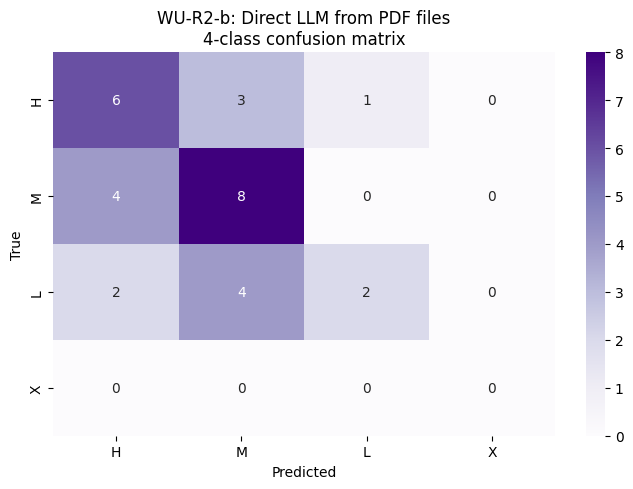

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_true, y_pred, labels=labels)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels,
            cmap="Purples", ax=ax)
ax.set_title("WU-R2-B: Direct LLM from PDF files\n4-class confusion matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
plt.savefig("notebooks/results/relevance_llm_direct_pdf_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

## Mismatch Analysis

Spot-check `relevance_reasoning` on mismatches.

In [10]:
mismatches = results_df[results_df["gt_relevance"] != results_df["pred_relevance"]].copy()
print(f"Mismatches: {len(mismatches)}/{len(results_df)} ({len(mismatches)/len(results_df):.1%})")

for _, row in mismatches.iterrows():
    print(f"\n--- Record {row['id']} ---")
    print(f"  GT mechanistic: {row['gt_relevance']}  |  Human label: {row.get('human_relevance')}  |  Pred: {row['pred_relevance']}")
    print(f"  pdf_local_path: {row.get('pdf_local_path')}")
    print(f"  has_dataset: {row.get('has_dataset')}")
    print(f"  data_type: {row.get('data_type')}")
    print(f"  temporal: {row.get('temp_range_i')}–{row.get('temp_range_f')}")
    print(f"  spatial: {row.get('spatial_range_km2')} km²")
    reasoning = row.get("relevance_reasoning", "")
    if reasoning:
        print(f"  Reasoning: {reasoning[:200]}")

Mismatches: 14/30 (46.7%)

--- Record 11 ---
  GT mechanistic: M  |  Human label: M  |  Pred: H
  pdf_local_path: data\pdfs\fuster\10.1371_journal.pone.0073695.pdf
  has_dataset: True
  data_type: ['time_series']
  temporal: 1999.0–2011.0
  spatial: 7250.0 km²
  Reasoning: Long-term (1999–2011) GPS/VHF telemetry time-series on a threatened woodland caribou population (primary data), covering a study area of ~7,250 km² and producing repeated location records and derived 

--- Record 24 ---
  GT mechanistic: H  |  Human label: H  |  Pred: L
  pdf_local_path: data\pdfs\fuster\10.1002_ece3.3906.pdf
  has_dataset: True
  data_type: ['genetic_analysis']
  temporal: 2008.0–2009.0
  spatial: nan km²
  Reasoning: Primary data are microsatellite genotypes (genetic_analysis) collected and deposited (Dryad). Sampling occurred over two years (2008–2009) only, and the paper does not state an explicit spatial area (

--- Record 27 ---
  GT mechanistic: M  |  Human label: M  |  Pred: H
  pdf_local_pat

## Summary Comparison Table

This notebook writes the `R2-B` direct-LLM outputs for PDF files and then rebuilds
`notebooks/results/relevance_comparison_summary.csv` from the mechanistic summaries plus any available direct-LLM summaries.

That keeps the shared comparison artifact aligned with the split `R2-A` / `R2-B` nomenclature.

In [11]:
METHOD_LABEL = "R2-B: Direct LLM from PDF files vs Fuster MC+Modulators"
OUTPUT_PREDICTIONS_NAME = "relevance_llm_direct_pdf_predictions.csv"
OUTPUT_SUMMARY_NAME = "relevance_llm_direct_pdf_summary.json"

results_dir = Path("notebooks/results")
results_dir.mkdir(parents=True, exist_ok=True)

results_df.to_csv(results_dir / OUTPUT_PREDICTIONS_NAME, index=False)
print(f"Saved predictions: notebooks/results/{OUTPUT_PREDICTIONS_NAME}")

summary = {
    "method": METHOD_LABEL,
    "model": MODEL,
    "target": "MC_relevance_modifiers",
    "diagnostic_target": "dataset_relevance",
    "prediction_source": prediction_source,
    "n_records": int(len(results_df)),
    "target_labels": present_labels,
    "macro_f1_present_labels": round(macro_f1_r2, 3),
    "macro_f1_all_labels": round(macro_f1_r2_all, 3),
    "binary_f1_relevant": round(f1_r2, 3),
    "binary_precision": round(p_r2, 3),
    "binary_recall": round(r_r2, 3),
    "diagnostic_vs_human": {
        "macro_f1_present_labels": round(macro_f1_r2_human, 3),
        "binary_f1_relevant": round(f1_r2_human, 3),
        "binary_precision": round(p_r2_human, 3),
        "binary_recall": round(r_r2_human, 3),
    },
    "prompt_hash_current": PROMPT_HASH,
    "schema_hash": SCHEMA_HASH,
    "total_cost_usd": round(total_cost, 4),
}
print("\nSummary:")
for k, v in summary.items():
    print(f"  {k}: {v}")

with open(results_dir / OUTPUT_SUMMARY_NAME, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)
print(f"\nSaved summary: notebooks/results/{OUTPUT_SUMMARY_NAME}")


def _read_rows(csv_name: str, allowed_methods: list[str]) -> list[dict]:
    path = results_dir / csv_name
    if not path.exists():
        return []
    df = pd.read_csv(path)
    return df[df["Method"].isin(allowed_methods)].to_dict(orient="records")


def _summary_json_to_row(json_name: str) -> dict | None:
    path = results_dir / json_name
    if not path.exists():
        return None
    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)
    return {
        "Method": data["method"],
        "4-class macro F1": data["macro_f1_present_labels"],
        "Binary F1 (relevant)": data["binary_f1_relevant"],
        "Binary P": data["binary_precision"],
        "Binary R": data["binary_recall"],
    }

rows = []
rows.extend(_read_rows(
    "relevance_mechanistic_summary.csv",
    [
        "R0: Rules on GT features vs Fuster MC+Modulators",
        "R1-A: Rules on abstract/repository-description LLM features vs Fuster MC+Modulators",
        "Diagnostic: Fuster MC+Modulators vs human dataset_relevance",
    ],
))
rows.extend(_read_rows(
    "relevance_mechanistic_pdf_summary.csv",
    ["R1-B: Rules on PDF-derived LLM features vs Fuster MC+Modulators"],
))
for json_name in ["relevance_llm_direct_summary.json", "relevance_llm_direct_pdf_summary.json"]:
    row = _summary_json_to_row(json_name)
    if row is not None:
        rows.append(row)

comparison_df = pd.DataFrame(rows).drop_duplicates(subset="Method", keep="last")
order = [
    "R0: Rules on GT features vs Fuster MC+Modulators",
    "R1-A: Rules on abstract/repository-description LLM features vs Fuster MC+Modulators",
    "R1-B: Rules on PDF-derived LLM features vs Fuster MC+Modulators",
    "R2-A: Direct LLM from abstract/repository-description text vs Fuster MC+Modulators",
    "R2-B: Direct LLM from PDF files vs Fuster MC+Modulators",
    "Diagnostic: Fuster MC+Modulators vs human dataset_relevance",
]
comparison_df["Method"] = pd.Categorical(comparison_df["Method"], categories=order, ordered=True)
comparison_df = comparison_df.sort_values("Method").reset_index(drop=True)
comparison_df.to_csv(results_dir / "relevance_comparison_summary.csv", index=False)
print("Saved comparison: notebooks/results/relevance_comparison_summary.csv")
comparison_df

Saved predictions: notebooks/results/relevance_llm_direct_pdf_predictions.csv

Summary:
  method: R2-B: Direct LLM from PDF files vs Fuster MC+Modulators
  model: gpt-5-mini
  target: MC_relevance_modifiers
  diagnostic_target: dataset_relevance
  prediction_source: fresh_api_calls
  n_records: 30
  target_labels: ['H', 'M', 'L']
  macro_f1_present_labels: 0.501
  macro_f1_all_labels: 0.375
  binary_f1_relevant: 0.857
  binary_precision: 0.778
  binary_recall: 0.955
  diagnostic_vs_human: {'macro_f1_present_labels': 0.266, 'binary_f1_relevant': 0.756, 'binary_precision': 0.63, 'binary_recall': 0.944}
  prompt_hash_current: 17e880ab
  schema_hash: 152e9399
  total_cost_usd: 0.4551

Saved summary: notebooks/results/relevance_llm_direct_pdf_summary.json
Saved comparison: notebooks/results/relevance_comparison_summary.csv


,Method,4-class macro F1,Binary F1 (relevant),Binary P,Binary R
0,R0: Rules on GT features vs Fuster MC+Modulators,1.000,1.000,1.000,1.000
1,R1-A: Rules on abstract/repository-description...,0.317,0.533,1.000,0.364
2,R1-B: Rules on PDF-derived LLM features vs Fus...,0.486,0.714,0.750,0.682
3,R2-A: Direct LLM from abstract/repository-desc...,0.381,0.483,1.000,0.318
4,R2-B: Direct LLM from PDF files vs Fuster MC+M...,0.501,0.857,0.778,0.955
5,Diagnostic: Fuster MC+Modulators vs human data...,0.491,0.850,0.773,0.944
